# 🌤️ Turkey Weather Forecast — Analysis Notebook


**Pipeline:**
1. EDA — exploratory analysis of 20+ years of Turkish weather data
2. Feature Engineering — temporal, physical, and geographic features
3. Multi-Output Regression — predict 7 physical variables (temp, humidity, pressure, etc.)
4. Classification — predict weather condition (Sunny / Cloudy / Rain / Snow)

**Key Design Decisions:**
- `precipitation` excluded from classifier features (data leakage)
- `Partly Cloudy` merged into `Sunny` (insufficient samples, F1 ~0.17)
- Region feature (Turkey's 7 geographic zones) added to improve humidity prediction
- Temporal train/test split: train < 2024, test ≥ 2024

## Cell 1: Imports & Configuration

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, accuracy_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12

CUTOFF_YEAR = 2024
print("Imports complete")

Imports complete


## Cell 2: Load & Merge Data

In [22]:
def find_file(filename, folder="data"):
    for path in [os.path.join(folder, filename),
                 os.path.join("..", folder, filename),
                 filename]:
        if os.path.exists(path):
            return path
    return None

master_path = find_file("Turkey_Weather_Master.csv")
locs_path   = find_file("locations.csv")

df   = pd.read_csv(master_path)
locs = pd.read_csv(locs_path)

df = df.merge(locs[['plaka', 'lat', 'lon']],
              left_on='plate_code', right_on='plaka', how='left')
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'].dt.year > 2003]

print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Cities        : {df['plate_code'].nunique()}")
df.head()

Dataset shape : (650916, 15)
Date range    : 2004-01-01 → 2025-12-31
Cities        : 81


,date,city,plate_code,max_temp,min_temp,precipitation,wind_speed,weather_code,humidity,pressure,radiation,weather_desc,plaka,lat,lon
366,2004-01-01 21:00:00+00:00,ADANA,1,9.2845,6.9845,14.300000,16.862455,61.0,74.91662,1009.9908,2.26,Rain: Slight,1,37.0,35.321333
367,2004-01-02 21:00:00+00:00,ADANA,1,11.1345,7.2845,11.799999,15.379206,61.0,85.55408,1009.5457,4.17,Rain: Slight,1,37.0,35.321333
368,2004-01-03 21:00:00+00:00,ADANA,1,12.3345,8.3845,26.599998,12.434340,63.0,90.85163,1010.9041,4.08,Rain: Moderate,1,37.0,35.321333
369,2004-01-04 21:00:00+00:00,ADANA,1,12.8845,7.9845,17.300000,9.565437,61.0,93.72599,1008.2779,4.76,Rain: Slight,1,37.0,35.321333
370,2004-01-05 21:00:00+00:00,ADANA,1,12.3345,7.1845,9.700001,10.805998,61.0,92.22939,1007.8614,5.79,Rain: Slight,1,37.0,35.321333


## Cell 3: Exploratory Data Analysis (EDA)

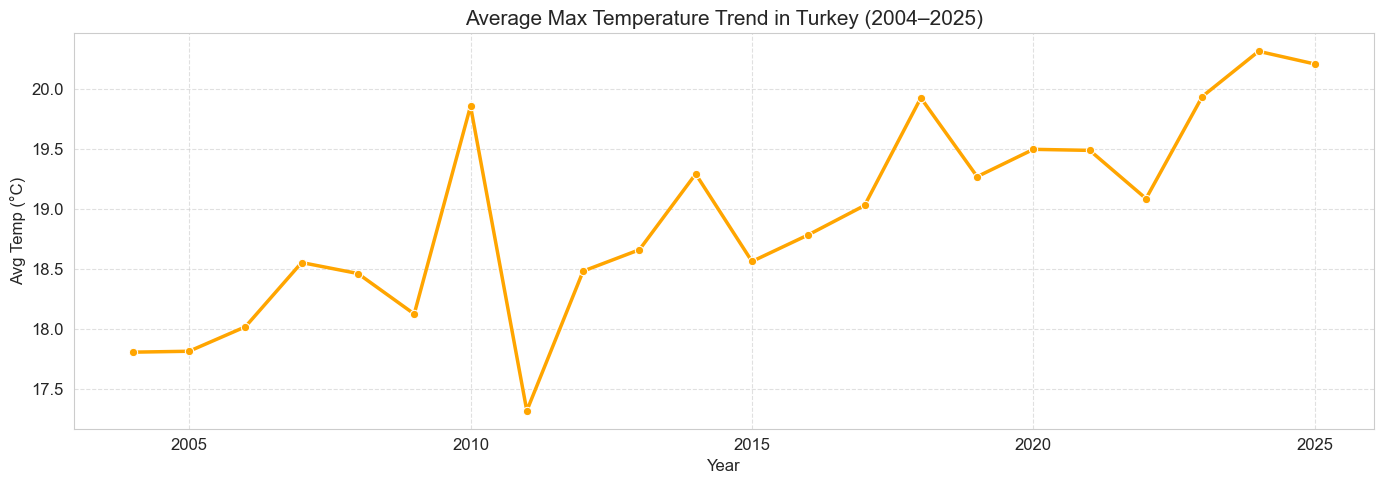

In [23]:
# --- 3a. Average Max Temperature Trend ---
df['year'] = df['date'].dt.year
yearly_avg = df.groupby('year')['max_temp'].mean()

plt.figure(figsize=(14, 5))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values,
             marker='o', color='orange', linewidth=2.5)
plt.title("Average Max Temperature Trend in Turkey (2004–2025)", fontsize=15)
plt.ylabel("Avg Temp (°C)")
plt.xlabel("Year")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

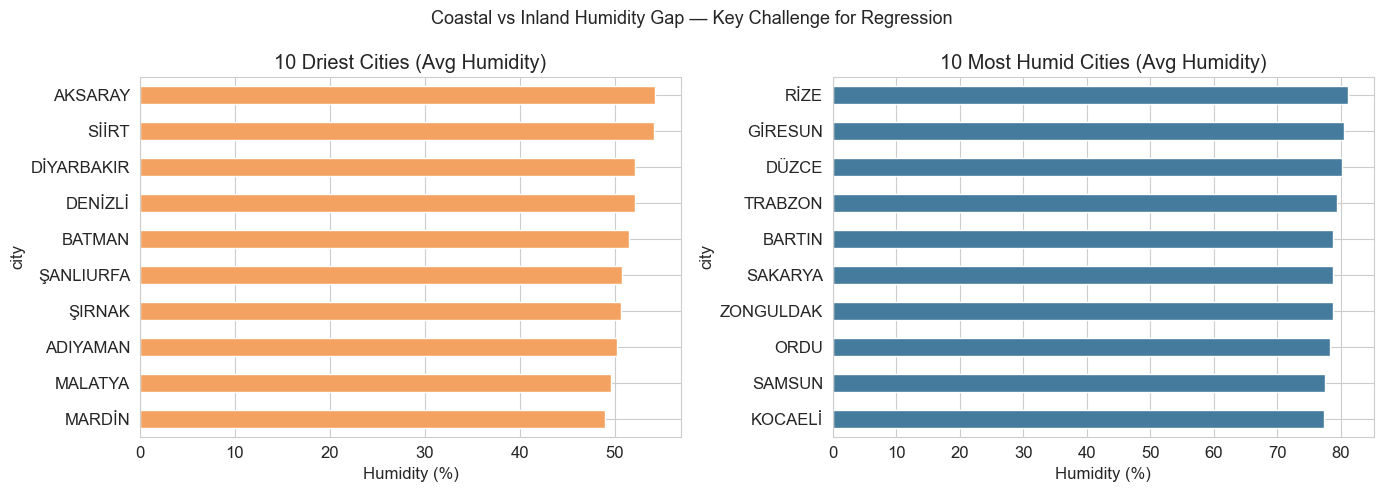

Humidity range across cities: 49.0% (driest) → 81.2% (most humid)


In [5]:
# --- 3b. Humidity distribution by city (top 10 highest vs lowest) ---
city_humidity = df.groupby('city')['humidity'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
city_humidity.head(10).plot(kind='barh', ax=axes[0], color='#f4a261')
axes[0].set_title("10 Driest Cities (Avg Humidity)")
axes[0].set_xlabel("Humidity (%)")

city_humidity.tail(10).plot(kind='barh', ax=axes[1], color='#457b9d')
axes[1].set_title("10 Most Humid Cities (Avg Humidity)")
axes[1].set_xlabel("Humidity (%)")

plt.suptitle("Coastal vs Inland Humidity Gap — Key Challenge for Regression", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Humidity range across cities: "
      f"{city_humidity.min():.1f}% (driest) → {city_humidity.max():.1f}% (most humid)")

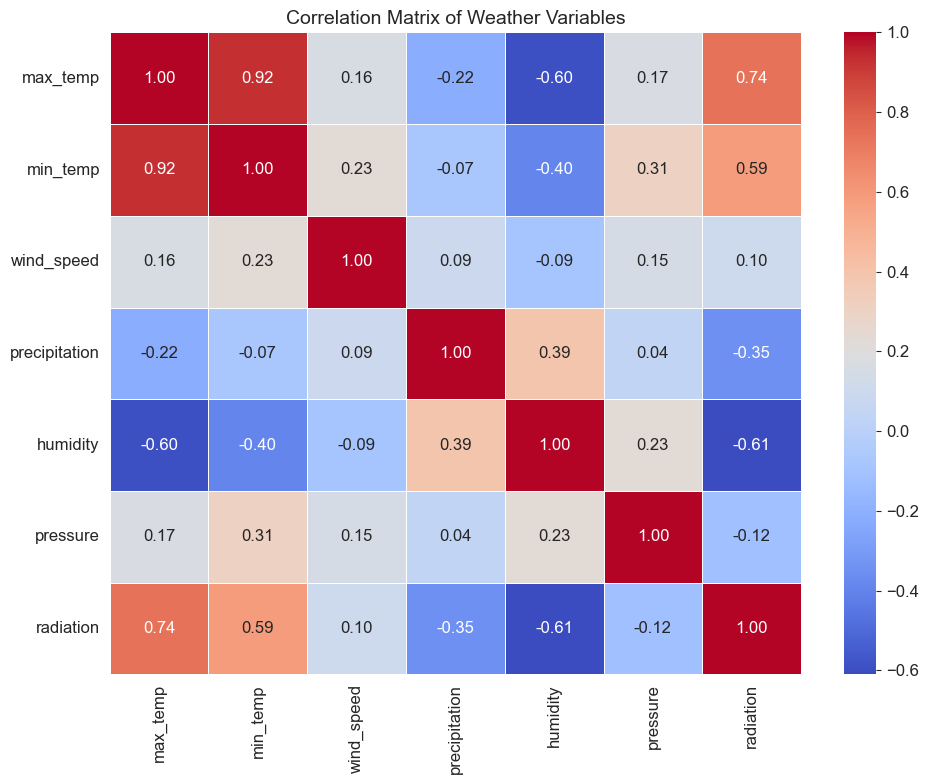

In [24]:
# --- 3c. Correlation Matrix ---
numeric_cols = ['max_temp', 'min_temp', 'wind_speed',
                'precipitation', 'humidity', 'pressure', 'radiation']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm',
            fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Weather Variables", fontsize=14)
plt.tight_layout()
plt.show()

## Cell 4: Feature Engineering

In [25]:
print("Generating features...")

# Temporal features
df['month']       = df['date'].dt.month
df['day']         = df['date'].dt.day
df['day_of_year'] = df['date'].dt.dayofyear

# Physical feature: diurnal temperature range
# High range → clear sky; low range → cloudy/rainy
df['temp_range'] = df['max_temp'] - df['min_temp']

# Geographic feature: Turkey's 7 standard regions
# Motivation: coastal cities (Rize ~81% humidity) vs inland (Mardin ~49%)
# lat/lon alone doesn't capture this — region adds explicit climate zone signal
def assign_region(lat, lon):
    if lat > 40.5:                        return 'Karadeniz'
    elif lat > 39.5 and lon < 31:         return 'Marmara'
    elif lon < 29.5 and lat < 40.5:       return 'Ege'
    elif lat < 37.5 and lon < 36:         return 'Akdeniz'
    elif lon > 38 and lat > 37.5:         return 'Dogu_Anadolu'
    elif lon > 36 and lat < 37.5:         return 'Guneydogu_Anadolu'
    else:                                 return 'Ic_Anadolu'

df['region'] = df.apply(lambda r: assign_region(r['lat'], r['lon']), axis=1)

le_region = LabelEncoder()
df['region_encoded'] = le_region.fit_transform(df['region'])

print("\nRegion distribution:")
print(df['region'].value_counts())

# Weather label simplification (4 classes)
# Note: 'Partly Cloudy' (code 2) merged into 'Sunny'
#   Reason: only ~8% of data, F1 score was 0.17 — model couldn't learn it reliably
def simplify_weather(code):
    code = int(code)
    if code in [0, 1, 2]:                                          return "Sunny"
    elif code in [3, 45, 48]:                                      return "Cloudy"
    elif code in [51,53,55, 61,63,65, 80,81,82, 95,96,99]:        return "Rain"
    elif code in [71,73,75, 77,85,86, 66,67]:                      return "Snow"
    else:                                                           return "Unknown"

df['weather_simple'] = df['weather_code'].apply(simplify_weather)
df = df[df['weather_simple'] != 'Unknown'].copy()

print("\nWeather class distribution:")
print(df['weather_simple'].value_counts())

df[['date', 'region', 'temp_range', 'weather_simple']].head()

Generating features...

Region distribution:
region
Karadeniz            200900
Dogu_Anadolu         152684
Ic_Anadolu           128576
Guneydogu_Anadolu     48216
Ege                   48216
Marmara               40180
Akdeniz               32144
Name: count, dtype: int64

Weather class distribution:
weather_simple
Rain      210933
Sunny     201895
Cloudy    180643
Snow       57445
Name: count, dtype: int64


,date,region,temp_range,weather_simple
366,2004-01-01 21:00:00+00:00,Akdeniz,2.300000,Rain
367,2004-01-02 21:00:00+00:00,Akdeniz,3.850001,Rain
368,2004-01-03 21:00:00+00:00,Akdeniz,3.950000,Rain
369,2004-01-04 21:00:00+00:00,Akdeniz,4.900000,Rain
370,2004-01-05 21:00:00+00:00,Akdeniz,5.150000,Rain


## Cell 5: Model 1 — Multi-Output Regression

Predicts 7 physical variables simultaneously: `max_temp`, `min_temp`, `precipitation`, `wind_speed`, `humidity`, `pressure`, `radiation`.

These predictions are then fed into the Classifier as input features.

In [9]:
REG_FEATURES = ['lat', 'lon', 'year', 'month', 'day', 'day_of_year', 'region_encoded']
REG_TARGETS  = ['max_temp', 'min_temp', 'precipitation',
                'wind_speed', 'humidity', 'pressure', 'radiation']

df_reg = df.dropna(subset=REG_FEATURES + REG_TARGETS).copy()

X_reg = df_reg[REG_FEATURES]
y_reg = df_reg[REG_TARGETS]

X_reg_train = X_reg[df_reg['year'] < CUTOFF_YEAR]
y_reg_train = y_reg[df_reg['year'] < CUTOFF_YEAR]
X_reg_test  = X_reg[df_reg['year'] >= CUTOFF_YEAR]
y_reg_test  = y_reg[df_reg['year'] >= CUTOFF_YEAR]

print(f"Train: {len(X_reg_train):,} | Test: {len(X_reg_test):,}")

# Train Random Forest (native multi-output) and XGBoost (wrapped)
reg_models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=20, n_jobs=-1, random_state=42),
    "XGBoost": MultiOutputRegressor(
        XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                     subsample=0.8, n_jobs=-1, random_state=42, verbosity=0)),
    "LightGBM": MultiOutputRegressor(
        LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                      n_jobs=-1, random_state=42, verbose=-1))
}

reg_results = {}

for name, model in reg_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_reg_train, y_reg_train)
    preds = model.predict(X_reg_test)
    preds_df = pd.DataFrame(preds, columns=REG_TARGETS)
    y_test_r = y_reg_test.reset_index(drop=True)

    target_maes = {col: round(mean_absolute_error(y_test_r[col], preds_df[col]), 3)
                   for col in REG_TARGETS}
    avg_mae = round(mean_absolute_error(y_test_r, preds_df), 3)
    reg_results[name] = {'per_target': target_maes, 'avg': avg_mae}

    print(f"  Average MAE: {avg_mae}")
    for t, m in target_maes.items():
        flag = " !!!" if t == 'humidity' and m > 8 else ""
        print(f"    {t:<15} {m}{flag}")

Train: 591,705 | Test: 59,211

Training Random Forest...
  Average MAE: 4.078
    max_temp        3.425
    min_temp        2.666
    precipitation   2.413
    wind_speed      3.894
    humidity        9.875 !!!
    pressure        3.379
    radiation       2.892

Training XGBoost...
  Average MAE: 4.153
    max_temp        3.347
    min_temp        2.584
    precipitation   2.662
    wind_speed      3.946
    humidity        10.449 !!!
    pressure        3.324
    radiation       2.759

Training LightGBM...
  Average MAE: 4.13
    max_temp        3.371
    min_temp        2.557
    precipitation   2.656
    wind_speed      3.957
    humidity        10.302 !!!
    pressure        3.339
    radiation       2.732


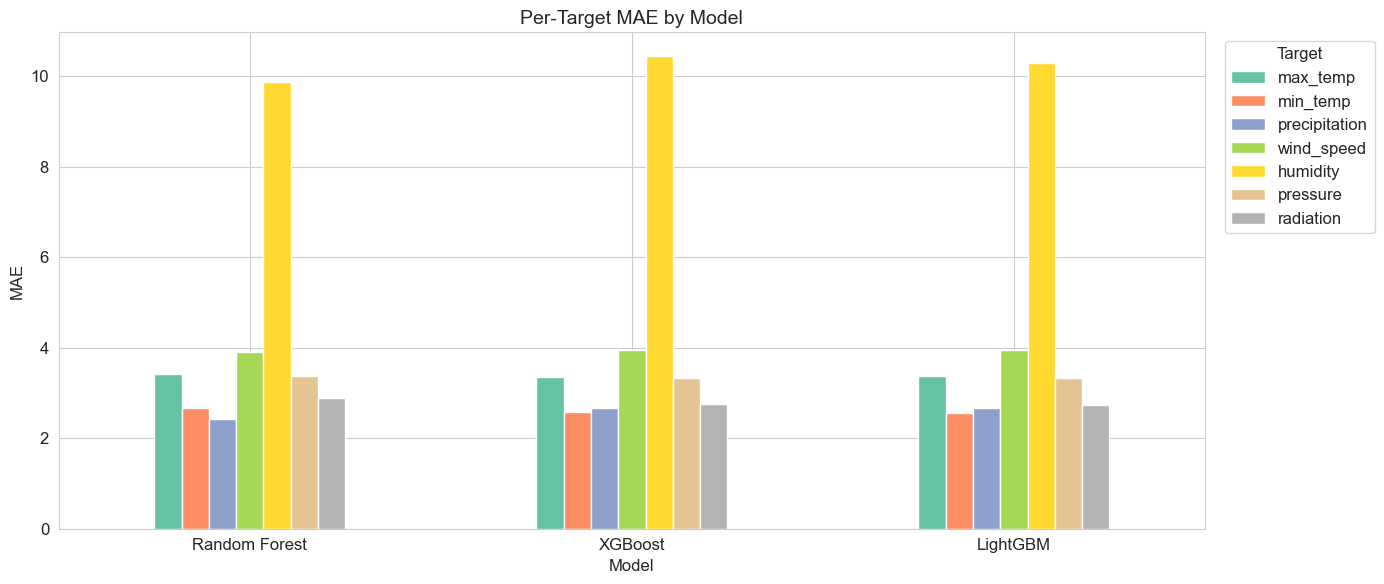


Summary Table:
               Random Forest  XGBoost  LightGBM
max_temp               3.425    3.347     3.371
min_temp               2.666    2.584     2.557
precipitation          2.413    2.662     2.656
wind_speed             3.894    3.946     3.957
humidity               9.875   10.449    10.302
pressure               3.379    3.324     3.339
radiation              2.892    2.759     2.732
Average                4.078    4.153     4.130


In [11]:
# --- Per-Target MAE Comparison Chart ---
mae_df = pd.DataFrame({name: v['per_target'] for name, v in reg_results.items()})

ax = mae_df.T.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='white')
plt.title("Per-Target MAE by Model", fontsize=14)
plt.ylabel("MAE")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(title="Target", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nSummary Table:")
summary = mae_df.copy()
summary.loc['Average'] = {name: reg_results[name]['avg'] for name in reg_results}
print(summary.to_string())

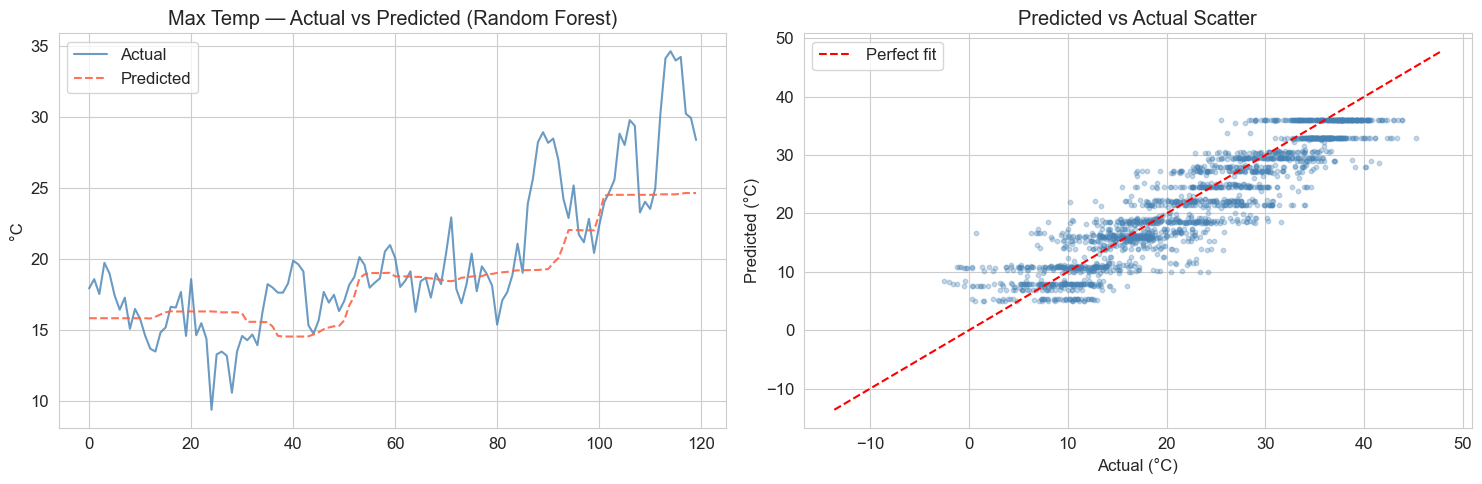

In [31]:
# --- Actual vs Predicted: max_temp (best performing target) ---
best_reg_name = min(reg_results, key=lambda k: reg_results[k]['avg'])
best_reg = reg_models[best_reg_name]

preds_best = pd.DataFrame(best_reg.predict(X_reg_test), columns=REG_TARGETS)
y_test_r   = y_reg_test.reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Time series sample
axes[0].plot(y_test_r['max_temp'].values[:120], label='Actual', color='steelblue', alpha=0.8)
axes[0].plot(preds_best['max_temp'].values[:120], label='Predicted',
             color='tomato', linestyle='--', alpha=0.9)
axes[0].set_title(f"Max Temp — Actual vs Predicted ({best_reg_name})")
axes[0].set_ylabel("°C")
axes[0].legend()

# Scatter
axes[1].scatter(y_test_r['max_temp'].values[:2000],
                preds_best['max_temp'].values[:2000],
                alpha=0.3, s=10, color='steelblue')
lims = [y_test_r['max_temp'].min(), y_test_r['max_temp'].max()]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_title("Predicted vs Actual Scatter")
axes[1].set_xlabel("Actual (°C)")
axes[1].set_ylabel("Predicted (°C)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../assets/regression_actual_vs_pred.png", dpi=150, bbox_inches='tight')
plt.show()

## Cell 6: Model 2 — Weather Condition Classification

**4 classes:** Sunny, Cloudy, Rain, Snow

**Important:** `precipitation` is intentionally excluded from classifier features.  
Including it would be data leakage: knowing today's rainfall trivially predicts 'Rain',  
making the model useless for genuine future forecasting.

In [30]:
CLF_FEATURES = [
    'lat', 'lon', 'year', 'month', 'day_of_year',
    'max_temp', 'min_temp', 'temp_range',
    'wind_speed', 'humidity', 'pressure', 'radiation'
    # 'precipitation' intentionally absent — data leakage
]
CLF_TARGET = 'weather_simple'

df_clf = df.dropna(subset=CLF_FEATURES + [CLF_TARGET]).copy()

le_clf = LabelEncoder()
df_clf['weather_encoded'] = le_clf.fit_transform(df_clf[CLF_TARGET])

X_clf = df_clf[CLF_FEATURES]
y_clf = df_clf['weather_encoded']

X_clf_train = X_clf[df_clf['year'] < CUTOFF_YEAR]
y_clf_train = y_clf[df_clf['year'] < CUTOFF_YEAR]
X_clf_test  = X_clf[df_clf['year'] >= CUTOFF_YEAR]
y_clf_test  = y_clf[df_clf['year'] >= CUTOFF_YEAR]

sample_weights = compute_sample_weight('balanced', y_clf_train)

print(f"Classes : {list(le_clf.classes_)}")
print(f"Train   : {len(X_clf_train):,} | Test: {len(X_clf_test):,}")
print("\nClass distribution (train):")
print(df_clf[df_clf['year'] < CUTOFF_YEAR][CLF_TARGET].value_counts())

clf_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=10,
        class_weight='balanced', n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, n_jobs=-1, random_state=42,
        eval_metric='mlogloss', verbosity=0),
    "LightGBM": LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)
}

clf_results = {}

for name, model in clf_models.items():
    print(f"\nTraining {name}...")
    if name == "XGBoost":
        model.fit(X_clf_train, y_clf_train, sample_weight=sample_weights)
    else:
        model.fit(X_clf_train, y_clf_train)

    y_pred = model.predict(X_clf_test)
    acc    = accuracy_score(y_clf_test, y_pred)
    clf_results[name] = {'model': model, 'preds': y_pred, 'acc': acc}

    print(f"Accuracy: {acc:.2%}")
    print(classification_report(y_clf_test, y_pred,
                                target_names=le_clf.classes_, zero_division=0))

Classes : ['Cloudy', 'Rain', 'Snow', 'Sunny']
Train   : 591,705 | Test: 59,211

Class distribution (train):
weather_simple
Rain      192346
Sunny     184810
Cloudy    161210
Snow       53339
Name: count, dtype: int64

Training Random Forest...
Accuracy: 68.54%
              precision    recall  f1-score   support

      Cloudy       0.60      0.62      0.61     19433
        Rain       0.81      0.68      0.74     18587
        Snow       0.57      0.81      0.67      4106
       Sunny       0.71      0.74      0.73     17085

    accuracy                           0.69     59211
   macro avg       0.67      0.71      0.69     59211
weighted avg       0.70      0.69      0.69     59211


Training XGBoost...
Accuracy: 67.38%
              precision    recall  f1-score   support

      Cloudy       0.59      0.60      0.60     19433
        Rain       0.79      0.67      0.73     18587
        Snow       0.53      0.84      0.65      4106
       Sunny       0.72      0.72      0.72     1

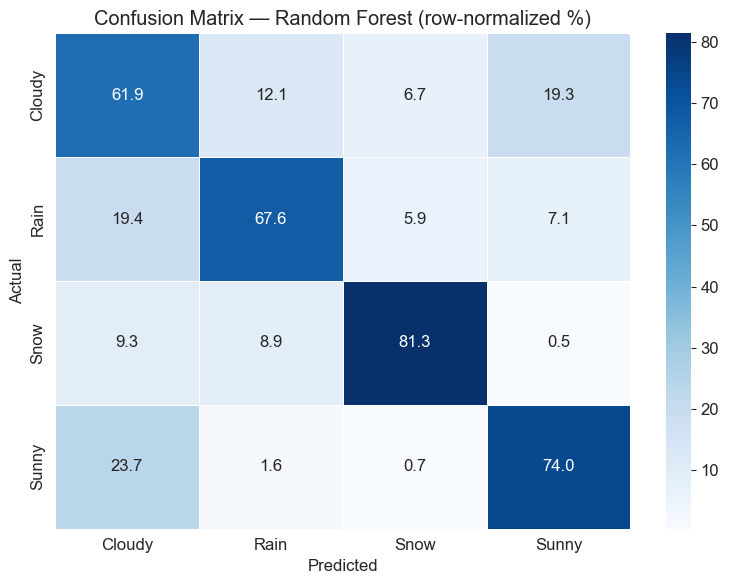


Best classifier: Random Forest — 68.54%


In [26]:
# --- Confusion Matrix (Best Classifier) ---
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['acc'])
best_preds    = clf_results[best_clf_name]['preds']

cm = confusion_matrix(y_clf_test, best_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le_clf.classes_,
            yticklabels=le_clf.classes_,
            linewidths=0.5)
plt.title(f"Confusion Matrix — {best_clf_name} (row-normalized %)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"\nBest classifier: {best_clf_name} — {clf_results[best_clf_name]['acc']:.2%}")

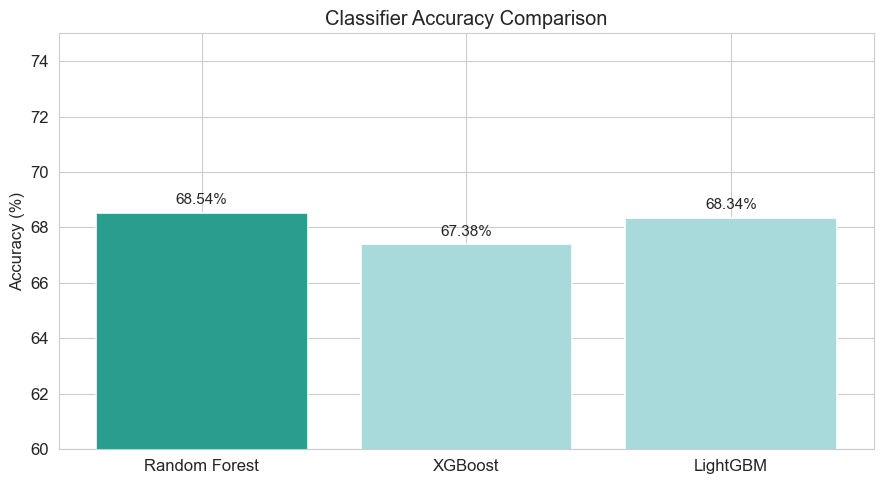

In [15]:
# --- Accuracy Comparison Bar Chart ---
names = list(clf_results.keys())
accs  = [clf_results[n]['acc'] * 100 for n in names]

colors = ['#2a9d8f' if n == best_clf_name else '#a8dadc' for n in names]

plt.figure(figsize=(9, 5))
bars = plt.bar(names, accs, color=colors, edgecolor='white', linewidth=1.2)
plt.ylim(60, 75)
plt.ylabel("Accuracy (%)")
plt.title("Classifier Accuracy Comparison")
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f"{acc:.2f}%", ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## Cell 7: Feature Importance

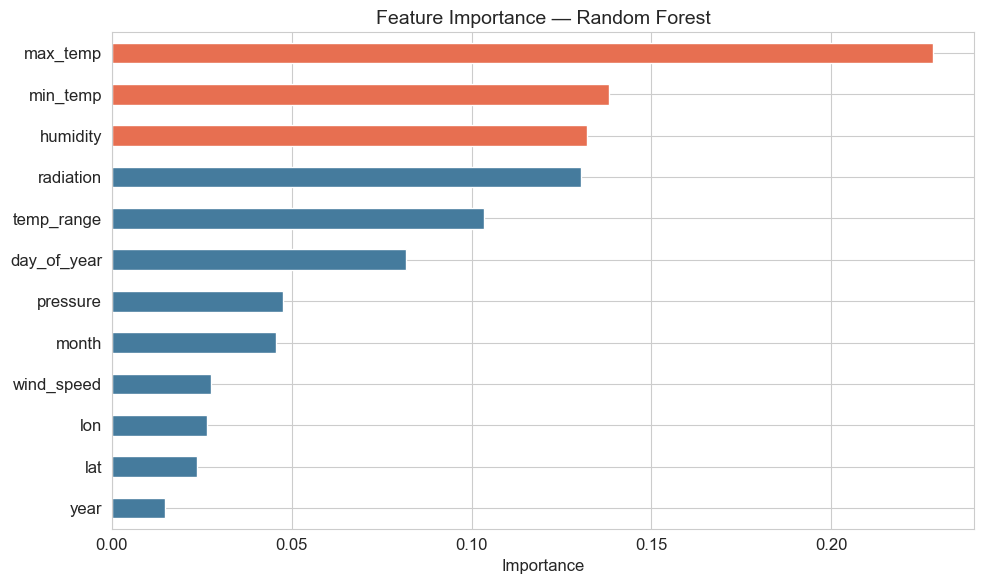

In [16]:
# Feature importance from best classifier
best_clf_model = clf_results[best_clf_name]['model']

if hasattr(best_clf_model, 'feature_importances_'):
    imp = pd.Series(best_clf_model.feature_importances_, index=CLF_FEATURES)
    imp = imp.sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    colors_imp = ['#e76f51' if v > imp.quantile(0.75) else '#457b9d' for v in imp]
    imp.plot(kind='barh', color=colors_imp, edgecolor='white')
    plt.title(f"Feature Importance — {best_clf_name}", fontsize=14)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_clf_name} does not expose feature_importances_")

## Cell 8: Results Summary

In [17]:
print("=" * 55)
print("REGRESSION — Average MAE (7 targets)")
print("=" * 55)
for name, res in sorted(reg_results.items(), key=lambda x: x[1]['avg']):
    print(f"  {name:<20} {res['avg']:.3f}")

print()
print("=" * 55)
print("CLASSIFICATION — Accuracy")
print("=" * 55)
for name, res in sorted(clf_results.items(), key=lambda x: -x[1]['acc']):
    print(f"  {name:<20} {res['acc']:.2%}")

print()
print("=" * 55)
print("KNOWN LIMITATIONS")
print("=" * 55)
print("  • Humidity MAE ~10% — coastal/inland gap hard to capture")
print("    with lat/lon alone; climatological mean would help")
print("  • Cloudy F1 ~0.61 — structural limit, Rain↔Cloudy")
print("    boundary is physically ambiguous")
print("  • Precipitation MAE ~2.4mm — skewed distribution,")
print("    zero-inflated (many dry days)")

REGRESSION — Average MAE (7 targets)
  Random Forest        4.078
  LightGBM             4.130
  XGBoost              4.153

CLASSIFICATION — Accuracy
  Random Forest        68.54%
  LightGBM             68.34%
  XGBoost              67.38%

KNOWN LIMITATIONS
  • Humidity MAE ~10% — coastal/inland gap hard to capture
    with lat/lon alone; climatological mean would help
  • Cloudy F1 ~0.61 — structural limit, Rain↔Cloudy
    boundary is physically ambiguous
  • Precipitation MAE ~2.4mm — skewed distribution,
    zero-inflated (many dry days)
